# Notebook 2: Train Models & Forecast
Reads IKB Excel directly. Trains 4 models. Saves winner as .pkl.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")

## 1. Load Data from Excel & Build Features

In [2]:
EXCEL_PATH = "../backend/data/IKB_overview_export_synthetic.xlsx"

raw = pd.read_excel(EXCEL_PATH)
monthly_raw = raw.groupby(["period", "company_group"])["amount_in_value"].sum().reset_index()
monthly = monthly_raw.pivot(index="period", columns="company_group", values="amount_in_value").fillna(0)
monthly.index = pd.to_datetime(monthly.index, format="%Y-%m")
monthly = monthly.sort_index()
monthly["Total"] = monthly.sum(axis=1)

depts = [c for c in monthly.columns if c != "Total"]
DEPT_MAP = {d: i for i, d in enumerate(sorted(depts))}
rows = []

for dept in depts:
    s = monthly[dept].values
    dates = monthly.index
    for i in range(12, len(s)):
        ytd = sum(s[j] for j in range(i) if dates[j].year == dates[i].year)
        rows.append({
            "department": dept, "date": dates[i],
            "month": dates[i].month, "year": dates[i].year,
            "lag_1": s[i-1], "lag_2": s[i-2], "lag_3": s[i-3],
            "rolling_avg_3": np.mean(s[i-3:i]),
            "trend": s[i-1] - s[i-2],
            "ytd_spend": ytd,
            "dept_code": DEPT_MAP[dept],
            "lag_4": s[i-4], "lag_5": s[i-5], "lag_6": s[i-6],
            "rolling_avg_6": np.mean(s[i-6:i]),
            "rolling_avg_12": np.mean(s[i-12:i]),
            "rolling_std_3": np.std(s[i-3:i]),
            "rolling_std_6": np.std(s[i-6:i]),
            "rolling_min_3": np.min(s[i-3:i]),
            "rolling_max_3": np.max(s[i-3:i]),
            "rolling_range_3": np.max(s[i-3:i]) - np.min(s[i-3:i]),
            "same_month_last_year": s[i-12],
            "acceleration": (s[i-1] - s[i-2]) - (s[i-2] - s[i-3]),
            "pct_change_1": ((s[i-1] - s[i-2]) / s[i-2] * 100) if s[i-2] != 0 else 0,
            "ratio_to_avg": s[i-1] / np.mean(s[:i]) if np.mean(s[:i]) != 0 else 1,
            "quarter": (dates[i].month - 1) // 3 + 1,
            "spend": s[i],
        })

ml_df = pd.DataFrame(rows)
feature_cols = [c for c in ml_df.columns if c not in ["department", "date", "spend"]]
X = ml_df[feature_cols]
y = ml_df["spend"]

# Time-based split
split_date = "2025-06-01"
train_mask = ml_df["date"] < split_date
test_mask = ml_df["date"] >= split_date
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Data: {len(monthly)} months, {len(depts)} departments")
print(f"ML dataset: {len(ml_df)} rows, {len(feature_cols)} features")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

results = []

Data: 71 months, 6 departments
ML dataset: 354 rows, 24 features
Train: 318 | Test: 36


---
## 2. Model 1: Linear Regression (Baseline)

In [3]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)
cv = -cross_val_score(lr, X_train, y_train, cv=3, scoring="neg_mean_absolute_error").mean()

print(f"Linear Regression")
print(f"  MAE: EUR {mae:.2f} | RMSE: EUR {rmse:.2f} | R2: {r2:.4f} | CV MAE: EUR {cv:.2f}")
results.append({"name": "Linear Regression", "mae": mae, "rmse": rmse, "r2": r2, "cv_mae": cv, "y_pred": y_pred_lr, "model": lr})

Linear Regression
  MAE: EUR 739.99 | RMSE: EUR 1022.73 | R2: 0.0197 | CV MAE: EUR 636.82


---
## 3. Model 2: Random Forest (Primary)

In [4]:
from sklearn.ensemble import RandomForestRegressor

print("Tuning Random Forest...")
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid={"n_estimators": [100, 200], "max_depth": [None, 10]},
    cv=3, scoring="neg_mean_absolute_error", n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print(f"Best: {rf_grid.best_params_}")

rf = rf_grid.best_estimator_
y_pred_rf = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
cv = -rf_grid.best_score_

print(f"\nRandom Forest")
print(f"  MAE: EUR {mae:.2f} | RMSE: EUR {rmse:.2f} | R2: {r2:.4f} | CV MAE: EUR {cv:.2f}")
results.append({"name": "Random Forest", "mae": mae, "rmse": rmse, "r2": r2, "cv_mae": cv, "y_pred": y_pred_rf, "model": rf})

Tuning Random Forest...
Best: {'max_depth': None, 'n_estimators': 100}

Random Forest
  MAE: EUR 753.46 | RMSE: EUR 1002.89 | R2: 0.0574 | CV MAE: EUR 637.95


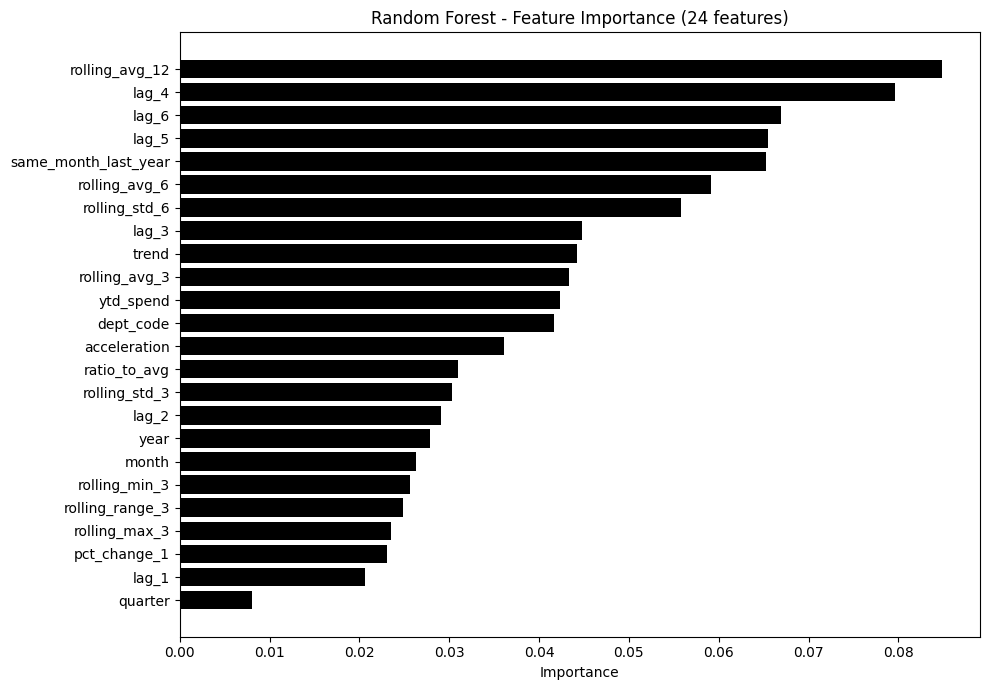

In [5]:
feat_imp = pd.DataFrame({"feature": X_train.columns, "importance": rf.feature_importances_})
feat_imp = feat_imp.sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp["feature"], feat_imp["importance"], color="black")
plt.xlabel("Importance")
plt.title("Random Forest - Feature Importance (24 features)")
plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=150)
plt.show()

---
## 4. Model 3: XGBoost (Comparison)

In [6]:
from xgboost import XGBRegressor

print("Tuning XGBoost...")
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid={"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 6]},
    cv=3, scoring="neg_mean_absolute_error", n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)
print(f"Best: {xgb_grid.best_params_}")

xgb = xgb_grid.best_estimator_
y_pred_xgb = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)
cv = -xgb_grid.best_score_

print(f"\nXGBoost")
print(f"  MAE: EUR {mae:.2f} | RMSE: EUR {rmse:.2f} | R2: {r2:.4f} | CV MAE: EUR {cv:.2f}")
results.append({"name": "XGBoost", "mae": mae, "rmse": rmse, "r2": r2, "cv_mae": cv, "y_pred": y_pred_xgb, "model": xgb})

Tuning XGBoost...
Best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

XGBoost
  MAE: EUR 788.73 | RMSE: EUR 1059.14 | R2: -0.0514 | CV MAE: EUR 634.21


---
## 5. Model 4: LSTM (Experimental)
Skip if PyTorch not installed.

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

seq_cols = ["lag_6", "lag_5", "lag_4", "lag_3", "lag_2", "lag_1"]
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_tr_s = scaler_X.fit_transform(X_train[seq_cols].values)
X_te_s = scaler_X.transform(X_test[seq_cols].values)
y_tr_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

X_tr_t = torch.FloatTensor(X_tr_s.reshape(-1, 6, 1))
y_tr_t = torch.FloatTensor(y_tr_s)
X_te_t = torch.FloatTensor(X_te_s.reshape(-1, 6, 1))
loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = LSTMModel().to(device)
opt = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(100):
    lstm_model.train()
    el = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(lstm_model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
        el += loss.item()
    if (epoch+1) % 25 == 0:
        print(f"  Epoch {epoch+1}/100 - Loss: {el/len(loader):.6f}")

lstm_model.eval()
with torch.no_grad():
    y_pred_lstm = scaler_y.inverse_transform(lstm_model(X_te_t.to(device)).cpu().numpy()).flatten()

mae = mean_absolute_error(y_test, y_pred_lstm)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2 = r2_score(y_test, y_pred_lstm)
print(f"\nLSTM")
print(f"  MAE: EUR {mae:.2f} | RMSE: EUR {rmse:.2f} | R2: {r2:.4f}")
results.append({"name": "LSTM", "mae": mae, "rmse": rmse, "r2": r2, "cv_mae": None, "y_pred": y_pred_lstm, "model": lstm_model})

  Epoch 25/100 - Loss: 0.028710
  Epoch 50/100 - Loss: 0.029020
  Epoch 75/100 - Loss: 0.028339
  Epoch 100/100 - Loss: 0.028283

LSTM
  MAE: EUR 780.52 | RMSE: EUR 1032.11 | R2: 0.0016


---
## 6. Model Comparison

In [8]:
comp = pd.DataFrame([{
    "Model": r["name"],
    "MAE (EUR)": round(r["mae"], 2),
    "RMSE (EUR)": round(r["rmse"], 2),
    "R2": round(r["r2"], 4),
    "CV MAE": f"EUR {r['cv_mae']:.2f}" if r["cv_mae"] else "N/A",
} for r in results])

print(comp.to_string(index=False))
winner = min(results, key=lambda x: x["mae"])
print(f"\nWINNER: {winner['name']} (MAE: EUR {winner['mae']:.2f})")

            Model  MAE (EUR)  RMSE (EUR)      R2     CV MAE
Linear Regression     739.99     1022.73  0.0197 EUR 636.82
    Random Forest     753.46     1002.89  0.0574 EUR 637.95
          XGBoost     788.73     1059.14 -0.0514 EUR 634.21
             LSTM     780.52     1032.11  0.0016        N/A

WINNER: Linear Regression (MAE: EUR 739.99)


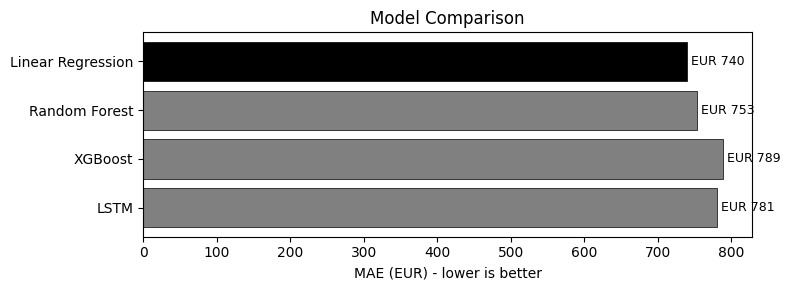

In [9]:
names = [r["name"] for r in results]
maes = [r["mae"] for r in results]
colors = ["gray"] * len(results)
colors[maes.index(min(maes))] = "black"

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(names, maes, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("MAE (EUR) - lower is better")
ax.set_title("Model Comparison")
ax.invert_yaxis()
for bar, v in zip(bars, maes):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f"EUR {v:.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=150)
plt.show()

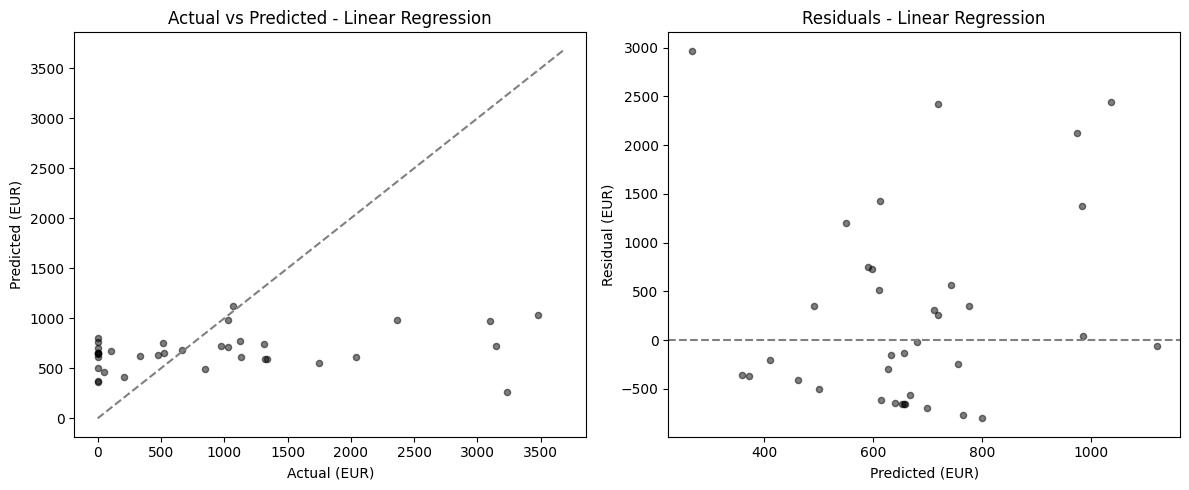

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, winner["y_pred"], alpha=0.5, color="black", s=20)
lims = [0, max(y_test.max(), max(winner["y_pred"])) + 200]
axes[0].plot(lims, lims, "--", color="gray")
axes[0].set_xlabel("Actual (EUR)"); axes[0].set_ylabel("Predicted (EUR)")
axes[0].set_title(f"Actual vs Predicted - {winner['name']}")

residuals = y_test.values - winner["y_pred"]
axes[1].scatter(winner["y_pred"], residuals, alpha=0.5, color="black", s=20)
axes[1].axhline(y=0, color="gray", linestyle="--")
axes[1].set_xlabel("Predicted (EUR)"); axes[1].set_ylabel("Residual (EUR)")
axes[1].set_title(f"Residuals - {winner['name']}")
plt.tight_layout()
plt.savefig("plot_actual_vs_predicted.png", dpi=150)
plt.show()

---
## 7. Forecast Next Month

In [11]:
best_sklearn = min([r for r in results if r["name"] != "LSTM"], key=lambda x: x["mae"])
best_model = best_sklearn["model"]
print(f"Using: {best_sklearn['name']}")

last_month = monthly.index[-1]
next_month = last_month + pd.DateOffset(months=1)
print(f"Last data: {last_month.strftime('%Y-%m')}")
print(f"Predicting: {next_month.strftime('%Y-%m')}")

forecasts = []
for dept in depts:
    s = monthly[dept].values
    current = float(s[-1])
    ytd = sum(float(v) for dt, v in zip(monthly.index, monthly[dept].values) if dt.year == next_month.year)
    
    row = pd.DataFrame([{
        "month": next_month.month, "year": next_month.year,
        "lag_1": s[-1], "lag_2": s[-2], "lag_3": s[-3],
        "rolling_avg_3": np.mean(s[-3:]), "trend": s[-1] - s[-2],
        "ytd_spend": ytd, "dept_code": DEPT_MAP[dept],
        "lag_4": s[-4], "lag_5": s[-5], "lag_6": s[-6],
        "rolling_avg_6": np.mean(s[-6:]), "rolling_avg_12": np.mean(s[-12:]),
        "rolling_std_3": np.std(s[-3:]), "rolling_std_6": np.std(s[-6:]),
        "rolling_min_3": np.min(s[-3:]), "rolling_max_3": np.max(s[-3:]),
        "rolling_range_3": np.max(s[-3:]) - np.min(s[-3:]),
        "same_month_last_year": s[-12],
        "acceleration": (s[-1] - s[-2]) - (s[-2] - s[-3]),
        "pct_change_1": ((s[-1] - s[-2]) / s[-2] * 100) if s[-2] != 0 else 0,
        "ratio_to_avg": s[-1] / np.mean(s) if np.mean(s) != 0 else 1,
        "quarter": (next_month.month - 1) // 3 + 1,
    }])
    predicted = float(max(best_model.predict(row)[0], 0))
    change_pct = round((predicted - current) / current * 100, 1) if current > 0 else 0
    forecasts.append({"department": dept, "current": round(current, 2), "predicted": round(predicted, 2), "change_pct": change_pct})

forecast_df = pd.DataFrame(forecasts)
print("\nDepartment Forecast:")
print(forecast_df.to_string(index=False))

total_pred = forecast_df["predicted"].sum()
highest = forecast_df.loc[forecast_df["predicted"].idxmax()]
print(f"\nTotal predicted: EUR {total_pred:,.0f}")
print(f"Highest spender: {highest['department']} (EUR {highest['predicted']:,.0f})")

Using: Linear Regression
Last data: 2025-11
Predicting: 2025-12

Department Forecast:
 department  current  predicted  change_pct
         CX  3145.98     515.45       -83.6
        ECX  1324.84     547.21       -58.7
  Marketing  3474.58    1055.30       -69.6
Recruitment  3233.95     364.19       -88.7
      Sales  1336.62       0.00      -100.0
    Support  3098.74     952.10       -69.3

Total predicted: EUR 3,434
Highest spender: Marketing (EUR 1,055)


---
## 8. Save Model

In [12]:
joblib.dump(best_model, "model_random_forest.pkl")
print(f"Saved: model_random_forest.pkl ({best_sklearn['name']})")
print(f"\nDone. Replace the .pkl in your model/ folder.")

Saved: model_random_forest.pkl (Linear Regression)

Done. Replace the .pkl in your model/ folder.
